In [ ]:
!nvidia-smi

Wed Sep 23 20:20:05 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   44C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

from PIL import Image
import torchvision.transforms as transforms
import torchvision.models as models
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Libraries loaded successfully!")
print(f"Active processing engine: {device}")

Libraries loaded successfully!
Active processing engine: cuda


In [ ]:
vgg = models.vgg19(pretrained=True).features.to(device).eval()

/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:08<00:00, 70.2MB/s]


In [ ]:
# Freeze the model's weights so I don't accidentally untrain it
for param in vgg.parameters():
    param.requires_grad = False

print("VGG19 Model successfully downloaded and locked into the GPU!")

VGG19 Model successfully downloaded and locked into the GPU!


In [ ]:
# Set the maximum image size , for faster processing I made it smaller
imsize = 512 if torch.cuda.is_available() else 128


loader = transforms.Compose([
    transforms.Resize((imsize, imsize)),
    transforms.ToTensor()]
)

def image_loader(image_name):
    image = Image.open(image_name)
    image = loader(image).unsqueeze(0)
    return image.to(device, torch.float)

style_img = image_loader("style.jpg")
content_img = image_loader("content.jpg")


print(f"Content Image loaded! Mathematical shape: {content_img.size()}")
print(f"Style Image loaded! Mathematical shape: {style_img.size()}")

Content Image loaded! Mathematical shape: torch.Size([1, 3, 512, 512])
Style Image loaded! Mathematical shape: torch.Size([1, 3, 512, 512])


In [ ]:
# 1. CONTENT LOSS FORMULA
class ContentLoss(nn.Module):
    def __init__(self, target):
        super(ContentLoss, self).__init__()
        self.target = target.detach()

    def forward(self, input):
        self.loss = nn.functional.mse_loss(input, self.target)
        return input

# 2. THE GRAM MATRIX (Extracts the texture and the brushstrokes)
def gram_matrix(input):
    a, b, c, d = input.size()
    features = input.view(a * b, c * d)
    G = torch.mm(features, features.t()) # Multiply the grid by itself to extract patterns
    return G.div(a * b * c * d) # Normalize the values

# 3. STYLE LOSS FORMULA
class StyleLoss(nn.Module):
    def __init__(self, target_feature):
        super(StyleLoss, self).__init__()
        self.target = gram_matrix(target_feature).detach()

    def forward(self, input):
        G = gram_matrix(input)
        # Calculate the distance between the generated texture and the painting's texture
        self.loss = nn.functional.mse_loss(G, self.target)
        return input

print("Loss functions defined, The system can measure style and content.")

Loss functions defined, The system can measure style and content.


Run 50: Style Loss: 0.0177 Content Loss: 0.0014
Run 100: Style Loss: 0.0175 Content Loss: 0.0015
Run 150: Style Loss: 0.0174 Content Loss: 0.0016
Run 200: Style Loss: 0.0174 Content Loss: 0.0016
Run 250: Style Loss: 0.0174 Content Loss: 0.0016
Run 300: Style Loss: 0.0173 Content Loss: 0.0016
Optimization Complete! The image has been restyled.


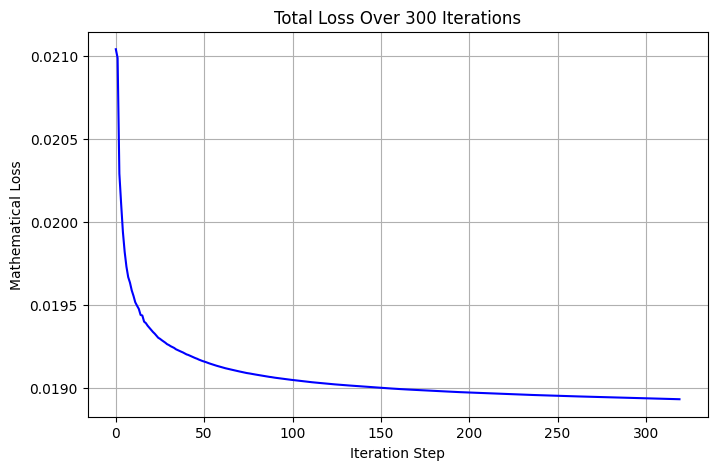

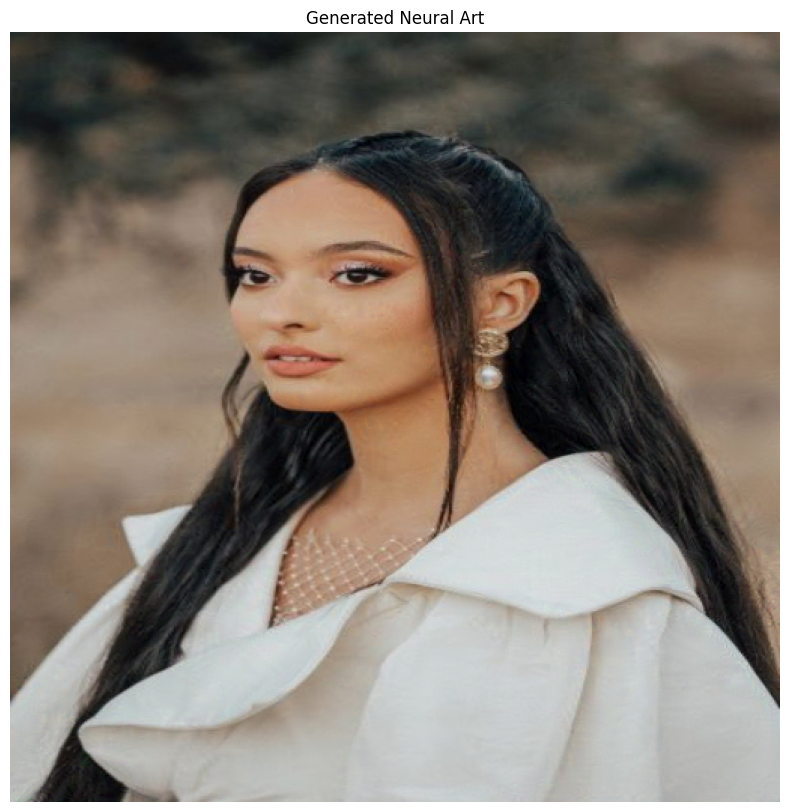

In [ ]:
# Create an empty list to store the loss numbers
loss_history = []

# clone the content image
input_img = content_img.clone()
input_img.requires_grad_(True)

# Set up the Optimizer
optimizer = optim.LBFGS([input_img])

style_weight = 1000000
content_weight = 1

# the Training Loop
run = [0]
while run[0] <= 300:
    def closure():
        with torch.no_grad():
            input_img.clamp_(0, 1)

        optimizer.zero_grad()

        features = vgg(input_img)
        content_features = vgg(content_img)
        c_loss = nn.functional.mse_loss(features, content_features.detach()) * content_weight

        style_features = vgg(style_img)
        s_loss = nn.functional.mse_loss(gram_matrix(features), gram_matrix(style_features).detach()) * style_weight

        loss = c_loss + s_loss
        loss.backward()

        #Save the loss number into my list every single run
        loss_history.append(loss.item())

        run[0] += 1
        if run[0] % 50 == 0:
            print(f"Run {run[0]}: Style Loss: {s_loss.item():.4f} Content Loss: {c_loss.item():.4f}")

        return loss

    optimizer.step(closure)

with torch.no_grad():
    input_img.clamp_(0, 1)

print("Optimization Complete! The image has been restyled.")

#  Draw the Loss Graph
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(loss_history, color='blue')
plt.title("Total Loss Over 300 Iterations")
plt.xlabel("Iteration Step")
plt.ylabel("Mathematical Loss")
plt.grid(True)
plt.show()
# ----------------------------------------------------

# display the new style
plt.figure(figsize=(10, 10))
output_image = input_img.cpu().clone().squeeze(0)
output_image = transforms.ToPILImage()(output_image)

plt.imshow(output_image)
plt.axis('off')
plt.title("Generated Neural Art")
plt.show()